In [ ]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
 
from credit_risk.data.ingestion import load_raw_accepted_loans
from credit_risk.data.target import build_target
from credit_risk.data.schema import INDETERMINATE_STATUSES

import warnings
warnings.filterwarnings("ignore")

### Data Loading

In [2]:
DATA_PATH = Path("../data/raw/accepted_2007_to_2018Q4.csv")
df: pl.DataFrame = load_raw_accepted_loans(DATA_PATH)
print(df.shape)

(2260668, 151)


### Data Structure

In [3]:
print(df.schema)
null_counts = df.null_count().to_dicts()[0]
null_pct = {k: round(v / df.height * 100, 2) for k, v in null_counts.items()}
top_missing = sorted(null_pct.items(), key=lambda x: -x[1])[:20]
for col, pct in top_missing:
    print(f"{col}: {pct}%")

Schema({'id': String, 'member_id': String, 'loan_amnt': Float64, 'funded_amnt': Float64, 'funded_amnt_inv': Float64, 'term': String, 'int_rate': Float64, 'installment': Float64, 'grade': String, 'sub_grade': String, 'emp_title': String, 'emp_length': String, 'home_ownership': String, 'annual_inc': Float64, 'verification_status': String, 'issue_d': String, 'loan_status': String, 'pymnt_plan': String, 'url': String, 'desc': String, 'purpose': String, 'title': String, 'zip_code': String, 'addr_state': String, 'dti': Float64, 'delinq_2yrs': Float64, 'earliest_cr_line': String, 'fico_range_low': Float64, 'fico_range_high': Float64, 'inq_last_6mths': Float64, 'mths_since_last_delinq': Float64, 'mths_since_last_record': Float64, 'open_acc': Float64, 'pub_rec': Float64, 'revol_bal': Float64, 'revol_util': Float64, 'total_acc': Float64, 'initial_list_status': String, 'out_prncp': Float64, 'out_prncp_inv': Float64, 'total_pymnt': Float64, 'total_pymnt_inv': Float64, 'total_rec_prncp': Float64, '

### Target & Censoring

In [4]:
status_counts = df.group_by("loan_status").len().sort("len", descending=True)
print(status_counts)
 
n_censored = df.filter(pl.col("loan_status").is_in(INDETERMINATE_STATUSES)).height
print(f"censored: {n_censored} ({n_censored / df.height * 100:.1f}%)")
 
labeled = build_target(df)
print(f"matured loans: {labeled.height}, default rate: {labeled['default_flag'].mean():.3f}")

shape: (9, 2)
┌─────────────────────────────────┬─────────┐
│ loan_status                     ┆ len     │
│ ---                             ┆ ---     │
│ str                             ┆ u32     │
╞═════════════════════════════════╪═════════╡
│ Fully Paid                      ┆ 1076751 │
│ Current                         ┆ 878317  │
│ Charged Off                     ┆ 268559  │
│ Late (31-120 days)              ┆ 21467   │
│ In Grace Period                 ┆ 8436    │
│ Late (16-30 days)               ┆ 4349    │
│ Does not meet the credit polic… ┆ 1988    │
│ Does not meet the credit polic… ┆ 761     │
│ Default                         ┆ 40      │
└─────────────────────────────────┴─────────┘
censored: 912569 (40.4%)
matured loans: 1348099, default rate: 0.200


### Time Distribution

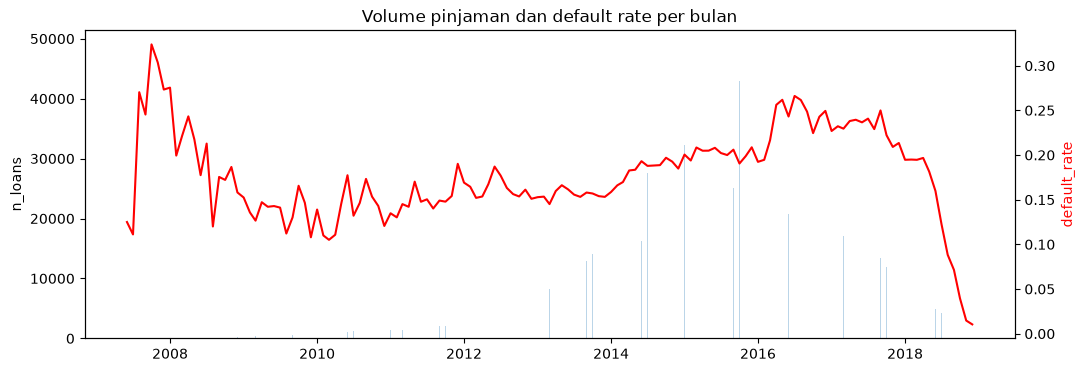

In [5]:
labeled = labeled.with_columns(
    pl.col("issue_d").str.strptime(pl.Date, "%b-%Y").alias("issue_date")
)
monthly = (
    labeled.group_by("issue_date")
    .agg(pl.len().alias("n_loans"), pl.col("default_flag").mean().alias("default_rate"))
    .sort("issue_date")
)
 
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(monthly["issue_date"], monthly["n_loans"], alpha=0.3, label="n_loans")
ax1.set_ylabel("n_loans")
ax2 = ax1.twinx()
ax2.plot(monthly["issue_date"], monthly["default_rate"], color="red")
ax2.set_ylabel("default_rate", color="red")
plt.title("Volume pinjaman dan default rate per bulan")
plt.show()

### Numeric Distribution

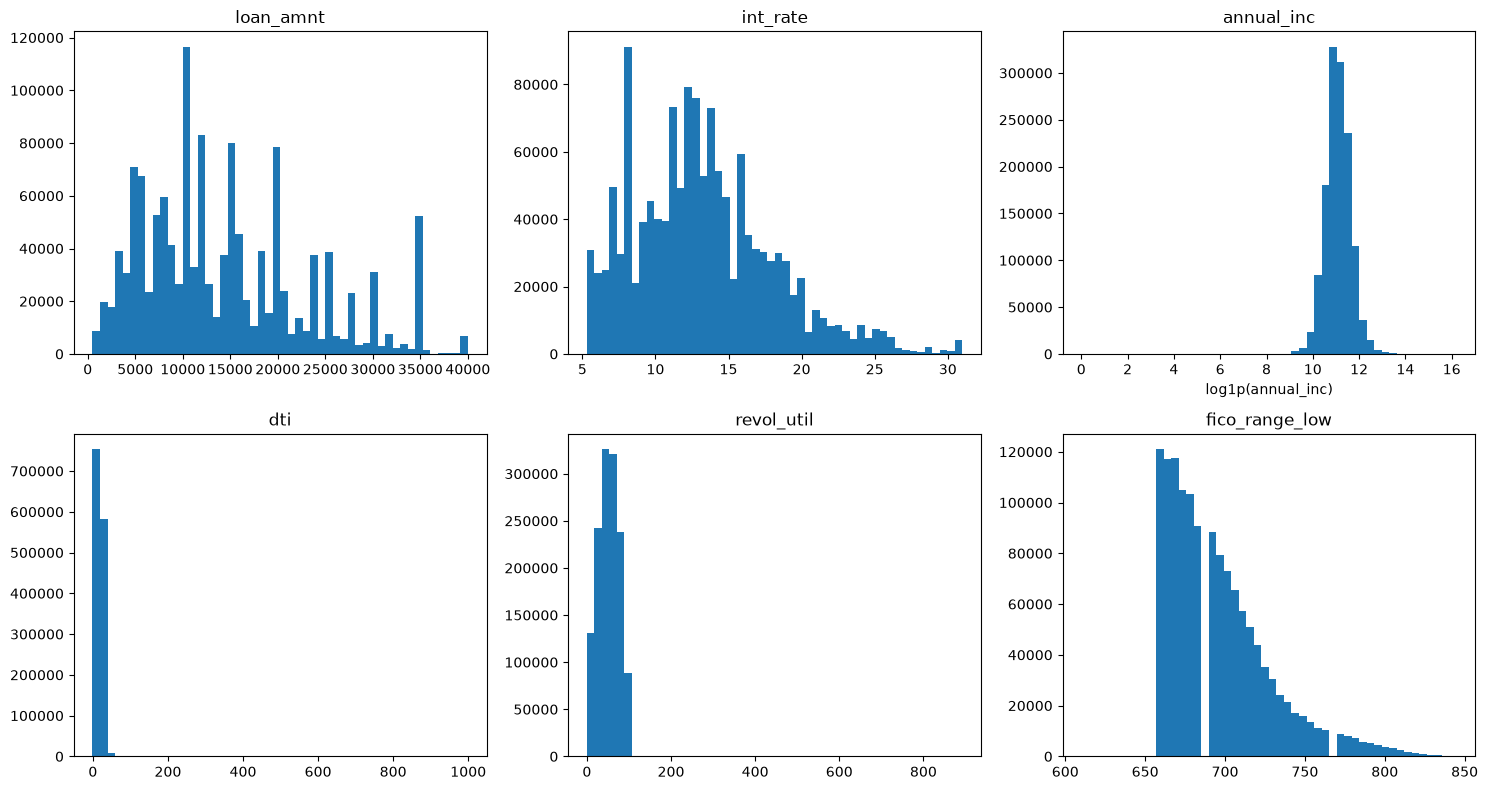

In [6]:
numeric_cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "revol_util", "fico_range_low"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    values = labeled[col].drop_nulls().to_numpy()
    if col == "annual_inc":
        values = np.log1p(values)
        ax.set_xlabel("log1p(annual_inc)")
    ax.hist(values, bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.show()  

### Categorical Distribution

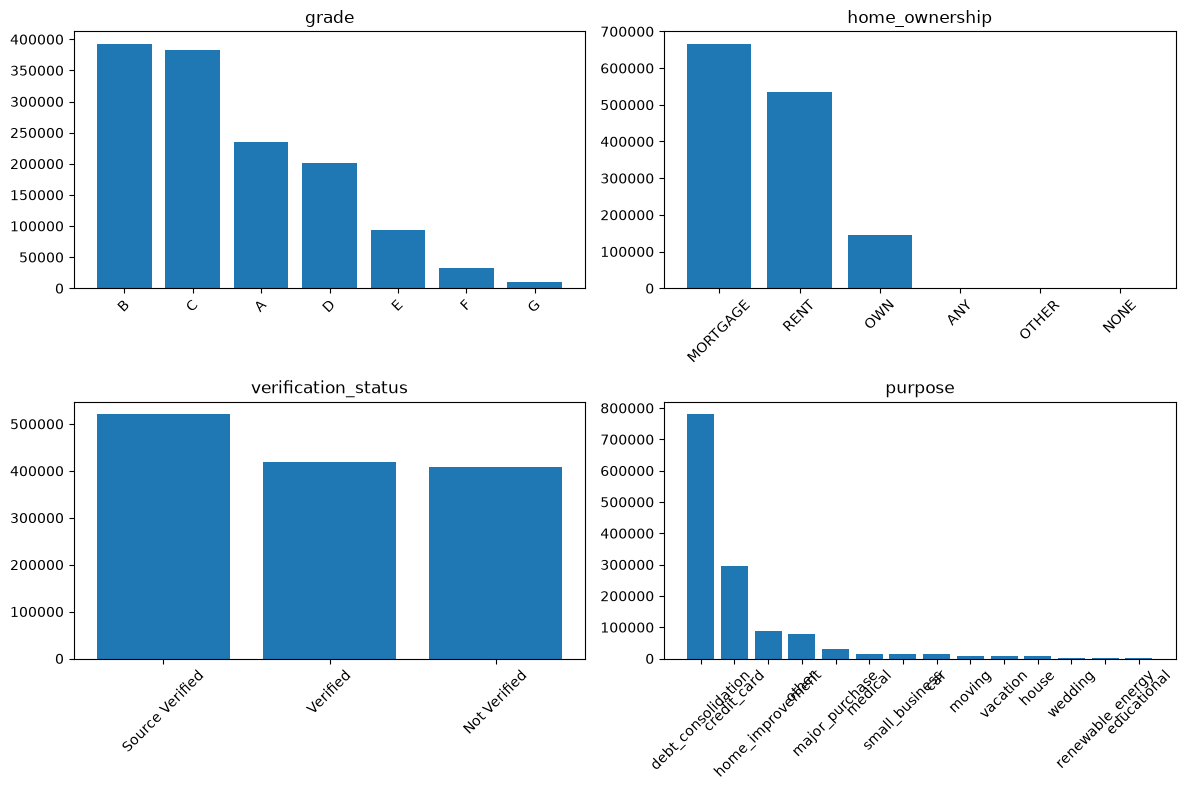

In [7]:
categorical_cols = ["grade", "home_ownership", "verification_status", "purpose"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, categorical_cols):
    counts = labeled.group_by(col).len().sort("len", descending=True)
    ax.bar(counts[col].to_list(), counts["len"].to_list())
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Sanity Check

shape: (7, 3)
┌───────┬────────┬──────────────┐
│ grade ┆ n      ┆ default_rate │
│ ---   ┆ ---    ┆ ---          │
│ str   ┆ u32    ┆ f64          │
╞═══════╪════════╪══════════════╡
│ A     ┆ 235193 ┆ 0.060435     │
│ B     ┆ 393102 ┆ 0.133963     │
│ C     ┆ 382323 ┆ 0.224431     │
│ D     ┆ 201657 ┆ 0.303803     │
│ E     ┆ 94192  ┆ 0.384311     │
│ F     ┆ 32306  ┆ 0.451464     │
│ G     ┆ 9326   ┆ 0.496676     │
└───────┴────────┴──────────────┘


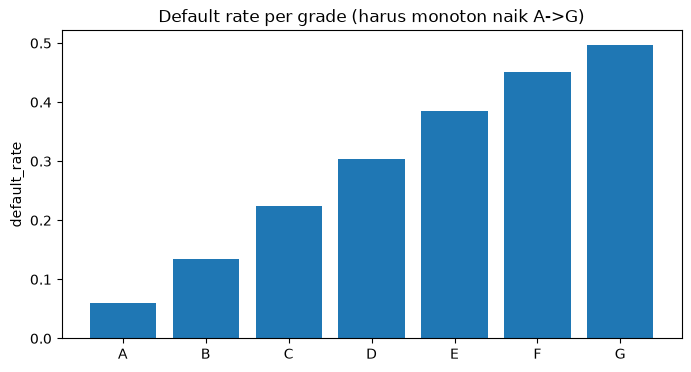

In [8]:
by_grade = (
    labeled.group_by("grade")
    .agg(pl.len().alias("n"), pl.col("default_flag").mean().alias("default_rate"))
    .sort("grade")
)
print(by_grade)
 
plt.figure(figsize=(8, 4))
plt.bar(by_grade["grade"], by_grade["default_rate"])
plt.title("Default rate per grade (harus monoton naik A->G)")
plt.ylabel("default_rate")
plt.show()

### Sanity Check Leakage Columns    

In [9]:
leak_check = (
    df.select(["loan_status", "total_pymnt", "recoveries"])
    .group_by("loan_status")
    .agg(
        pl.col("total_pymnt").mean().alias("avg_total_pymnt"),
        pl.col("recoveries").mean().alias("avg_recoveries"),
    )
)
print(leak_check)

shape: (9, 3)
┌─────────────────────────────────┬─────────────────┬────────────────┐
│ loan_status                     ┆ avg_total_pymnt ┆ avg_recoveries │
│ ---                             ┆ ---             ┆ ---            │
│ str                             ┆ f64             ┆ f64            │
╞═════════════════════════════════╪═════════════════╪════════════════╡
│ Default                         ┆ 8329.182        ┆ 0.0            │
│ Does not meet the credit polic… ┆ 4819.215266     ┆ 594.49976      │
│ Current                         ┆ 7997.493289     ┆ 0.0            │
│ Fully Paid                      ┆ 16453.244341    ┆ 0.0            │
│ Late (31-120 days)              ┆ 8885.138429     ┆ 0.0            │
│ Late (16-30 days)               ┆ 9870.608576     ┆ 0.0            │
│ In Grace Period                 ┆ 10550.682364    ┆ 0.0            │
│ Charged Off                     ┆ 8291.083571     ┆ 1209.456926    │
│ Does not meet the credit polic… ┆ 10539.320959    ┆ 0.0      

### Numeric Correlation

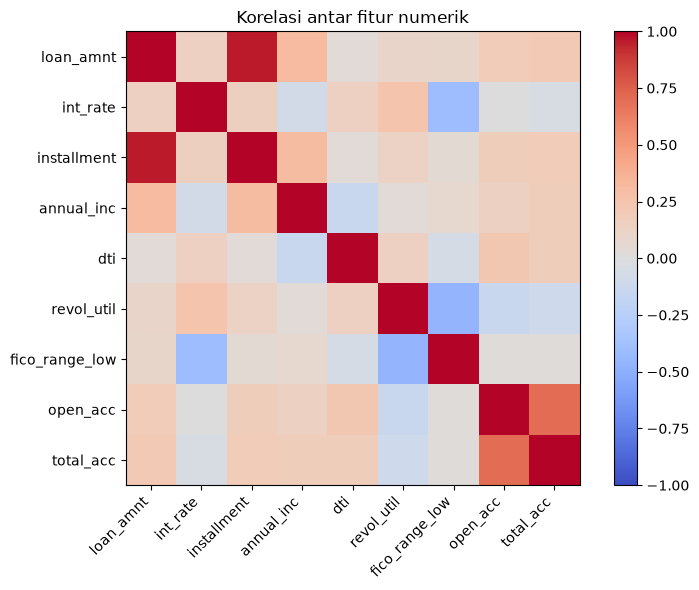

In [10]:
numeric_for_corr = [
    "loan_amnt", "int_rate", "installment", "annual_inc",
    "dti", "revol_util", "fico_range_low", "open_acc", "total_acc",
]
corr_df = labeled.select(numeric_for_corr).drop_nulls().to_pandas().corr()
 
plt.figure(figsize=(8, 6))
plt.imshow(corr_df, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(numeric_for_corr)), numeric_for_corr, rotation=45, ha="right")
plt.yticks(range(len(numeric_for_corr)), numeric_for_corr)
plt.colorbar()
plt.title("Korelasi antar fitur numerik")
plt.tight_layout()
plt.show()